In [10]:
#simple spam detection


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [2]:
# Features: number of spammy words
X = np.array([0, 1, 2, 3, 4, 5]).reshape(-1, 1)

# Labels: 0 = Not Spam, 1 = Spam
y = np.array([0, 0, 0, 1, 1, 1])

In [3]:
model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [4]:
# Test example: email with 2 spam words
prediction = model.predict([[2]])
probability = model.predict_proba([[2]])

print("Prediction (0=Not Spam, 1=Spam):", prediction)
print("Probability:", probability)

Prediction (0=Not Spam, 1=Spam): [0]
Probability: [[0.63658458 0.36341542]]


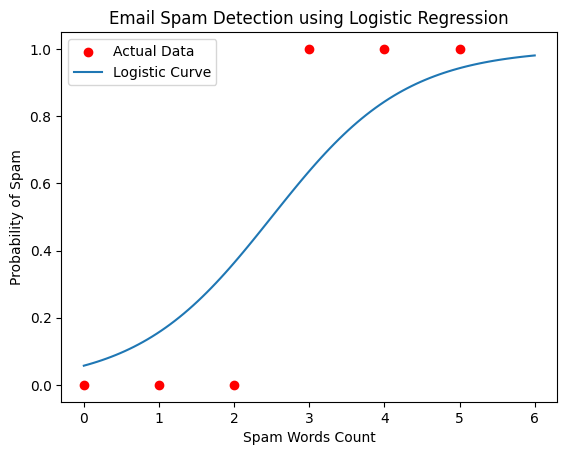

In [5]:
# Generate values for graph
x_values = np.linspace(0, 6, 100).reshape(-1, 1)
y_probs = model.predict_proba(x_values)[:, 1]

# Plot
plt.scatter(X, y, color='red', label="Actual Data")
plt.plot(x_values, y_probs, label="Logistic Curve")

plt.xlabel("Spam Words Count")
plt.ylabel("Probability of Spam")
plt.title("Email Spam Detection using Logistic Regression")
plt.legend()

plt.show()

Dataset Preview:
                                             message  label
0  Subject: enron methanol ; meter # : 988291\nth...      0
1  Subject: hpl nom for january 9 , 2001\n( see a...      0
2  Subject: neon retreat\nho ho ho , we ' re arou...      0
3  Subject: photoshop , windows , office . cheap ...      1
4  Subject: re : indian springs\nthis deal is to ...      0

Accuracy: 0.9884057971014493


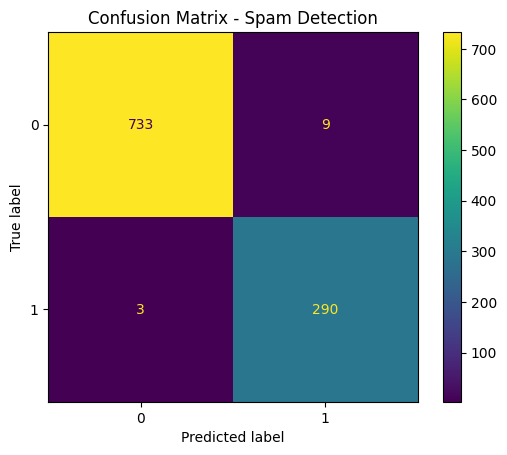


Test Message Prediction:
Spam


In [11]:
#dataset spam detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# STEP 1: Load Dataset
# -----------------------------
df = pd.read_csv("datasetspam.csv", encoding='latin-1')

# Keep only required columns
df = df[['text', 'label_num']]
df.columns = ['message', 'label']

print("Dataset Preview:")
print(df.head())

# -----------------------------
# STEP 2: Features & Target
# -----------------------------
X = df['message']
y = df['label']

# -----------------------------
# STEP 3: Text Vectorization
# -----------------------------
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

# -----------------------------
# STEP 4: Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# STEP 5: Train Model
# -----------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# -----------------------------
# STEP 6: Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# STEP 7: Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# -----------------------------
# STEP 8: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Spam Detection")
plt.show()

# -----------------------------
# STEP 9: Test Custom Message
# -----------------------------
sample = ["Congratulations! You won a free prize"]

sample_vec = vectorizer.transform(sample)
prediction = model.predict(sample_vec)

print("\nTest Message Prediction:")
print("Spam" if prediction[0] == 1 else "Not Spam")

In [12]:
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


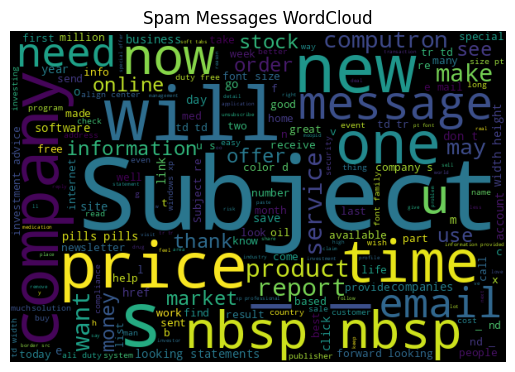

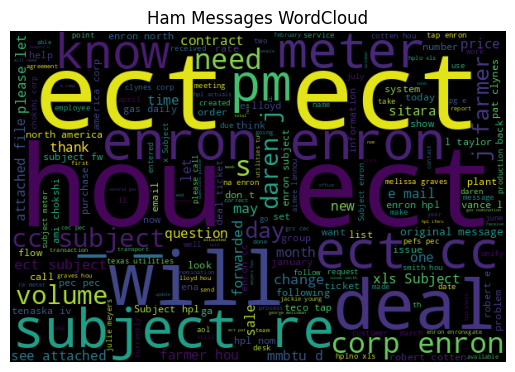

In [13]:
from wordcloud import WordCloud

# Spam messages
spam_words = " ".join(df[df['label'] == 1]['message'])

spam_wc = WordCloud(width=600, height=400).generate(spam_words)

plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam Messages WordCloud")
plt.show()


# Ham messages
ham_words = " ".join(df[df['label'] == 0]['message'])

ham_wc = WordCloud(width=600, height=400).generate(ham_words)

plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham Messages WordCloud")
plt.show()